In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv


In [2]:
file_path = "iris.csv"
df = pd.read_csv(file_path)
print(df.head(2))
print(df.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
(150, 5)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# Understanding the dataset
print(f"Max Sepal length and width: {max(df.sepal_length)} , {max(df.sepal_width)}")
print(f"Max Petal length and width: {max(df.petal_length)} , {max(df.petal_width)}")
print(df["species"].value_counts())
print(df.isnull().sum())

Max Sepal length and width: 7.9 , 4.4
Max Petal length and width: 6.9 , 2.5
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["species"] = label_encoder.fit_transform(df["species"])
df


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("species", axis=1)
y = df['species']
X_train, X_temp, y_train, y_temp = train_test_split(X, y , test_size=0.30, random_state=13, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=34,stratify=y_temp)

In [7]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(105, 4)
(22, 4)
(23, 4)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [9]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])
# Using the softmax activation function for multi-class classification (we have 3 classes)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

2026-09-27 17:22:15.081701: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(X_train,y_train,validation_data=(X_val, y_val),epochs=30,batch_size=12)
print(history.history.keys())

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4286 - loss: 0.9716 - val_accuracy: 0.5909 - val_loss: 0.8994
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7238 - loss: 0.8276 - val_accuracy: 0.7273 - val_loss: 0.7790
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8095 - loss: 0.7148 - val_accuracy: 0.7273 - val_loss: 0.6845
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8190 - loss: 0.6262 - val_accuracy: 0.7273 - val_loss: 0.6124
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8286 - loss: 0.5585 - val_accuracy: 0.7727 - val_loss: 0.5524
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8381 - loss: 0.5019 - val_accuracy: 0.7727 - val_loss: 0.5048
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8476 - loss: 0.4552 - val_accuracy: 0.7727 - val_loss: 0.4662
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8476 - loss: 0.4155 - val_accuracy: 0.7727 - val_loss: 0.4361
Epoch 9

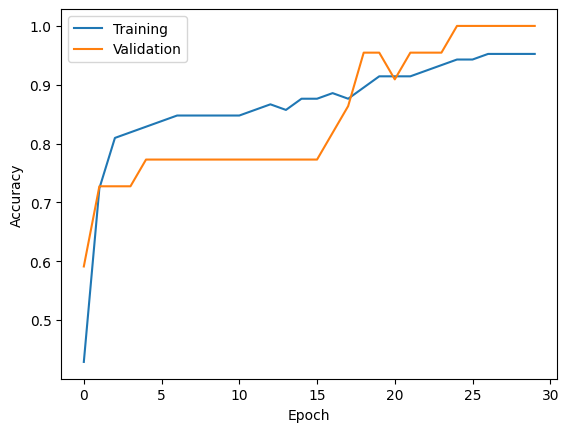

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

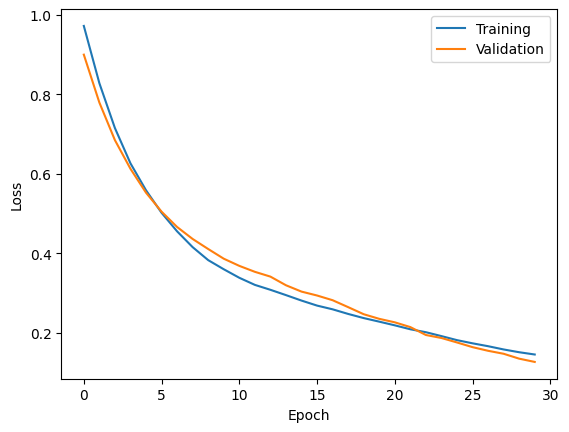

In [12]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.show()

In [13]:
# Training accuracy
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
# Testing accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy * 100:.2f}%")

Training Accuracy: 95.24%
Testing Accuracy:  100.00%
